
Average Benchmark Results (RSA Key Transport to AES Key):
Algorithm: RSA-4096-AES-Key-Transport
Average Key Gen & Encryption Time: 0.000183 seconds
Average Decryption & HKDF Time: 0.004296 seconds
Average Total Time: 0.004478 seconds
Shared Secrets Match: True
Derived Keys Match: True


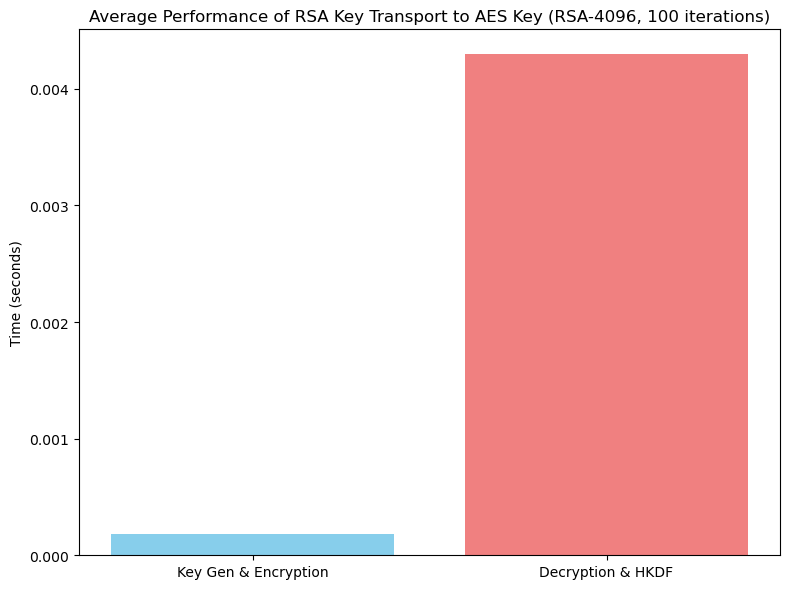

In [1]:
import logging
from pprint import pformat
from sys import stdout
import timeit
import pandas as pd # type: ignore
import matplotlib.pyplot as plt
import os

from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.kdf.hkdf import HKDF
from cryptography.hazmat.backends import default_backend
from cryptography.hazmat.primitives.asymmetric import rsa
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.primitives.asymmetric import padding  # Corrected import

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(stdout))

# Configuration for benchmarking
rsa_key_size = 4096  # Increased RSA key size for key transport
num_iterations = 100
salt_length = 32
salt = os.urandom(salt_length)
info = b'aes-key'
key_length = 32
symmetric_key_length = 32  # Length of the symmetric key (for AES) to transport

# Lists to store the results
results = []

# Benchmarking function for RSA key transport to AES key derivation
def benchmark_rsa_aes_key_transport_with_hkdf_timed(key_size):
    # --- RSA Key Generation (Recipient's long-term key) ---
    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=key_size,
        backend=default_backend()
    )
    public_key = private_key.public_key()

    # --- Key Generation & Encryption (Sender) ---
    keygen_encrypt_start = timeit.default_timer()
    # Sender generates a random symmetric key (for AES)
    session_key = os.urandom(symmetric_key_length)
    # Sender encrypts the session key with the recipient's public key
    ciphertext = public_key.encrypt(
        session_key,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None
        )
    )
    keygen_encrypt_end = timeit.default_timer()
    keygen_encrypt_time = keygen_encrypt_end - keygen_encrypt_start

    # --- Decryption & Key Derivation (Recipient) ---
    decrypt_hkdf_start = timeit.default_timer()
    # Recipient decrypts the ciphertext to get the session key
    decrypted_key = private_key.decrypt(
        ciphertext,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None
        )
    )
    # Recipient derives the AES key using HKDF on the session key
    hkdf = HKDF(
        algorithm=hashes.SHA256(),
        length=key_length,
        salt=salt,
        info=info,
        backend=default_backend()
    )
    aes_key = hkdf.derive(decrypted_key)
    decrypt_hkdf_end = timeit.default_timer()
    decrypt_hkdf_time = decrypt_hkdf_end - decrypt_hkdf_start

    total_time = keygen_encrypt_time + decrypt_hkdf_time

    return {
        "algorithm": f"RSA-{key_size}-AES-Key-Transport",
        "keygen_encrypt_time": keygen_encrypt_time,
        "decrypt_hkdf_time": decrypt_hkdf_time,
        "total_time": total_time,
        "shared_secrets_match": (session_key == decrypted_key),
        "derived_keys_match": True  # Always true if decryption is correct
    }

# Run the benchmark
benchmark_results = []
for _ in range(num_iterations):
    result = benchmark_rsa_aes_key_transport_with_hkdf_timed(rsa_key_size)
    benchmark_results.append(result)

# Create a pandas DataFrame from the results
df = pd.DataFrame(benchmark_results)

# Calculate the average times
average_keygen_encrypt_time = df["keygen_encrypt_time"].mean()
average_decrypt_hkdf_time = df["decrypt_hkdf_time"].mean()
average_total_time = df["total_time"].mean()

print("\nAverage Benchmark Results (RSA Key Transport to AES Key):")
print(f"Algorithm: RSA-{rsa_key_size}-AES-Key-Transport")
print(f"Average Key Gen & Encryption Time: {average_keygen_encrypt_time:.6f} seconds")
print(f"Average Decryption & HKDF Time: {average_decrypt_hkdf_time:.6f} seconds")
print(f"Average Total Time: {average_total_time:.6f} seconds")
print(f"Shared Secrets Match: {df['shared_secrets_match'].all()}")
print(f"Derived Keys Match: {df['derived_keys_match'].all()}")

# Visualization with Matplotlib
labels = ['Key Gen & Encryption', 'Decryption & HKDF']
times = [average_keygen_encrypt_time, average_decrypt_hkdf_time]

plt.figure(figsize=(8, 6))
plt.bar(labels, times, color=['skyblue', 'lightcoral'])
plt.ylabel("Time (seconds)")
plt.title(f"Average Performance of RSA Key Transport to AES Key (RSA-{rsa_key_size}, {num_iterations} iterations)")
plt.xticks(labels)
plt.tight_layout()
plt.show()